# EDA

## Импорт библиотек


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import ks_2samp

sns.set_theme(style="whitegrid")

## 1. Загрузка данных


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (751, 214)
Test shape: (250, 211)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


## 2. Анализ признаков (колонок)


Вывод колонок построчно, так проще


In [ ]:
for col in train.columns.tolist():
  print(col)

index
IC50, mM
CC50, mM
SI
MaxAbsEStateIndex
MaxEStateIndex
MinAbsEStateIndex
MinEStateIndex
qed
SPS
MolWt
HeavyAtomMolWt
ExactMolWt
NumValenceElectrons
NumRadicalElectrons
MaxPartialCharge
MinPartialCharge
MaxAbsPartialCharge
MinAbsPartialCharge
FpDensityMorgan1
FpDensityMorgan2
FpDensityMorgan3
BCUT2D_MWHI
BCUT2D_MWLOW
BCUT2D_CHGHI
BCUT2D_CHGLO
BCUT2D_LOGPHI
BCUT2D_LOGPLOW
BCUT2D_MRHI
BCUT2D_MRLOW
AvgIpc
BalabanJ
BertzCT
Chi0
Chi0n
Chi0v
Chi1
Chi1n
Chi1v
Chi2n
Chi2v
Chi3n
Chi3v
Chi4n
Chi4v
HallKierAlpha
Ipc
Kappa1
Kappa2
Kappa3
LabuteASA
PEOE_VSA1
PEOE_VSA10
PEOE_VSA11
PEOE_VSA12
PEOE_VSA13
PEOE_VSA14
PEOE_VSA2
PEOE_VSA3
PEOE_VSA4
PEOE_VSA5
PEOE_VSA6
PEOE_VSA7
PEOE_VSA8
PEOE_VSA9
SMR_VSA1
SMR_VSA10
SMR_VSA2
SMR_VSA3
SMR_VSA4
SMR_VSA5
SMR_VSA6
SMR_VSA7
SMR_VSA8
SMR_VSA9
SlogP_VSA1
SlogP_VSA10
SlogP_VSA11
SlogP_VSA12
SlogP_VSA2
SlogP_VSA3
SlogP_VSA4
SlogP_VSA5
SlogP_VSA6
SlogP_VSA7
SlogP_VSA8
SlogP_VSA9
TPSA
EState_VSA1
EState_VSA10
EState_VSA11
EState_VSA2
EState_VSA3
EState_VSA4
ESta

Определение целевых переменных


In [ ]:
target_cols = ["IC50, mM", "CC50, mM", "SI"]

Помимо целевых, есть индекс


In [ ]:
id_cols = ["index"]

Явное определение всех фичей


In [ ]:
feature_cols = [col for col in train.columns if col not in target_cols + id_cols]

Подытог


In [ ]:
print("Target columns:", target_cols)
print("ID columns:", id_cols)
print("Number of features:", len(feature_cols))

Target columns: ['IC50, mM', 'CC50, mM', 'SI']
ID columns: ['index']
Number of features: 210


## 3. Проверка пропусков


В train-выборке


In [ ]:
missing_train = train.isna().sum().sort_values(ascending=False)
print("Пропуски в трейне")
print(missing_train[missing_train > 0])

Пропуски в трейне
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
MaxPartialCharge       2
MinPartialCharge       2
BCUT2D_MWLOW           2
BCUT2D_MWHI            2
BCUT2D_MRLOW           2
BCUT2D_MRHI            2
BCUT2D_LOGPLOW         2
BCUT2D_LOGPHI          2
BCUT2D_CHGLO           2
BCUT2D_CHGHI           2
dtype: int64


В test-выборке


In [ ]:
missing_test = test.isna().sum().sort_values(ascending=False)
print("Пропуски в тесте:")
print(missing_test[missing_test > 0])

Пропуски в тесте:
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
MaxPartialCharge       1
BCUT2D_MRHI            1
BCUT2D_LOGPLOW         1
BCUT2D_LOGPHI          1
BCUT2D_CHGLO           1
BCUT2D_CHGHI           1
BCUT2D_MWLOW           1
BCUT2D_MWHI            1
BCUT2D_MRLOW           1
dtype: int64


Список колонок с пропусками в train


In [ ]:
missing_cols_train = missing_train[missing_train > 0].index.tolist()
# Выводим список колонок с пропусками в train и их количество
print("Список колонок с пропусками в train:\n", missing_cols_train)
print('Всего фичей с пропусками:', len(missing_cols_train))

Список колонок с пропусками в train:
 ['MaxAbsPartialCharge', 'MinAbsPartialCharge', 'MaxPartialCharge', 'MinPartialCharge', 'BCUT2D_MWLOW', 'BCUT2D_MWHI', 'BCUT2D_MRLOW', 'BCUT2D_MRHI', 'BCUT2D_LOGPLOW', 'BCUT2D_LOGPHI', 'BCUT2D_CHGLO', 'BCUT2D_CHGHI']
Всего фичей с пропусками: 12


Пропуски только в 12 признаках, количественно пропусков мало, будут заполнены медианными значениями


In [ ]:
for col in missing_cols_train:
    median_value = train[col].median()
    train[col] = train[col].fillna(median_value)
    test[col] = test[col].fillna(median_value)

print("Пропуски после заполнения:", train[missing_cols_train].isna().sum().sum())

Пропуски после заполнения: 0


## 7. Проверка типов признаков


Проверяем типы признаков: числовые / категориальные / текстовые

In [ ]:


numeric_features = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

# Текстовые признаки здесь маловероятны, но оставляем явную проверку на случай object/string столбцов
text_like_features = []
for col in categorical_features:
    avg_len = train[col].dropna().astype(str).str.len().mean()
    if pd.notna(avg_len) and avg_len > 20:
        text_like_features.append(col)

print(f"Числовые признаки: {len(numeric_features)}")
print(f"Категориальные признаки: {len(categorical_features)}")
print(f"Текстовые признаки: {len(text_like_features)}")

type_summary = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [train[col].dtype for col in feature_cols],
    "n_unique": [train[col].nunique(dropna=False) for col in feature_cols],
    "kind": ["numeric" if col in numeric_features else "other" for col in feature_cols]
})

display(type_summary.head(20))

if len(categorical_features) == 0:
    print("Вывод: все признаки в train/test числовые, категориальных и текстовых признаков нет.")


Числовые признаки: 210
Категориальные признаки: 0
Текстовые признаки: 0


,feature,dtype,n_unique,kind
0,MaxAbsEStateIndex,float64,623,numeric
1,MaxEStateIndex,float64,623,numeric
2,MinAbsEStateIndex,float64,621,numeric
3,MinEStateIndex,float64,626,numeric
4,qed,float64,602,numeric
5,SPS,float64,499,numeric
6,MolWt,float64,571,numeric
7,HeavyAtomMolWt,float64,500,numeric
8,ExactMolWt,float64,556,numeric
9,NumValenceElectrons,int64,107,numeric


Вывод: все признаки в train/test числовые, категориальных и текстовых признаков нет.


## 4. Анализ распределений target'ов


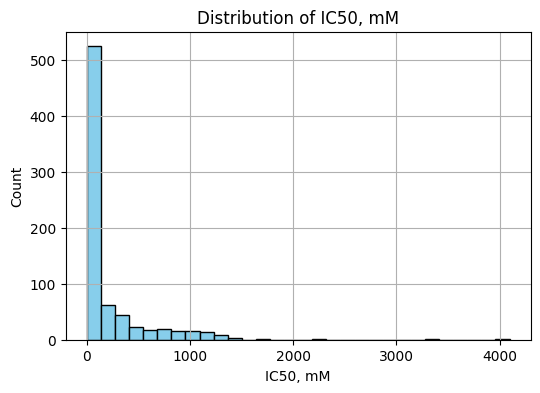

IC50, mM skewness: 3.7874


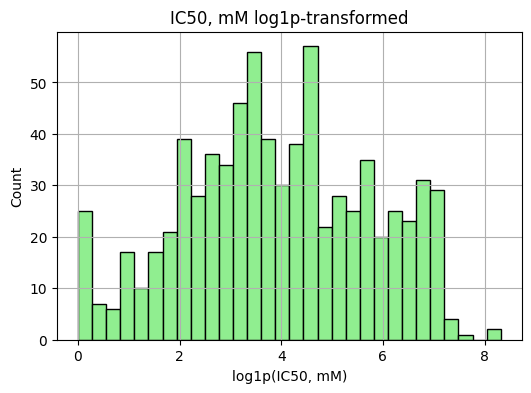

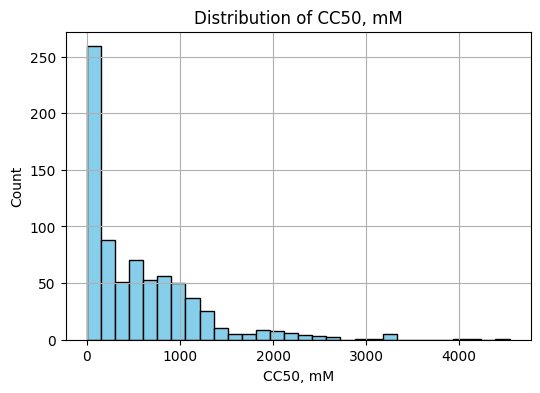

CC50, mM skewness: 2.0563


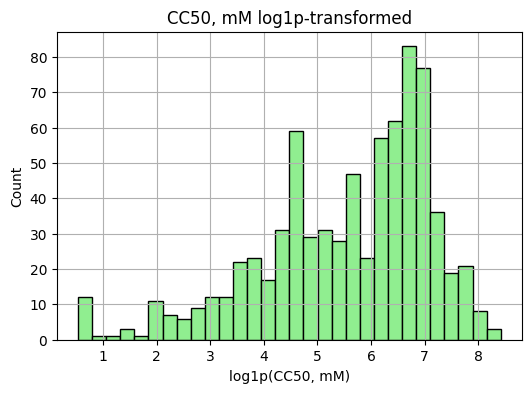

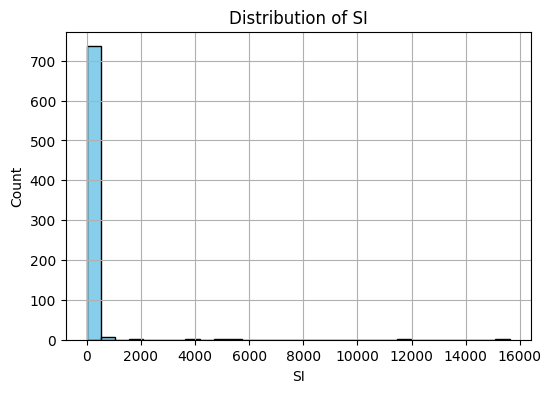

SI skewness: 15.6350


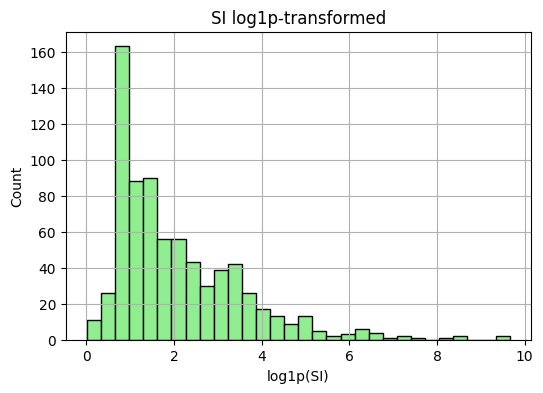

In [ ]:
for col in target_cols:
    plt.figure(figsize=(6,4))
    train[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    skewness = train[col].skew()
    print(f"{col} skewness: {skewness:.4f}")

    plt.figure(figsize=(6,4))
    np.log1p(train[col]).hist(bins=30, color='lightgreen', edgecolor='black')
    plt.title(f"{col} log1p-transformed")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.show()

1. IC50 (мкМ)

Распределение сильно правосторонне-скошено

Большинство значений сосредоточено около нуля, хвост тянется до ~4000 мкМ

После логарифмирования (log1p) распределение становится близким к нормальному, симметричным, без выраженных хвостов

Сильная асимметрия указывает на наличие редких высоких IC50, то есть соединений с очень слабой активностью

Лог-трансформация делает данные более пригодными для моделей, чувствительных к распределению (линейные модели, регрессия, нейросети)

Вывод
Для IC50 логарифмическая трансформация обязательна: устраняет перекос, стабилизирует дисперсию и улучшает обучаемость

2. CC50 (мкМ)

Распределение также правосторонне-скошено, но слабее, чем у IC50

Большинство значений низкие, хвост доходит до ~4000 мкМ

После log1p распределение становится плавным и почти симметричным

CC50 отражает токсичность: редкие высокие значения означают соединения с низкой токсичностью

Лог-трансформация улучшает интерпретируемость и снижает влияние экстремальных значений

CC50 также требует лог-трансформации для корректного моделирования и уменьшения влияния выбросов.

3. SI (Selectivity Index = CC50 / IC50)

Распределение экстремально скошено (skewness ≈ 15.6)

Большинство значений близки к нулю, но есть огромный хвост до ~16000

После log1p распределение становится широким, равномерным и гораздо более нормальным

SI — отношение двух сильно скошенных величин, поэтому исходное распределение всегда будет тяжёлым

Лог-трансформация делает SI пригодным для статистического анализа и ML

SI в исходном виде непригоден для моделирования. Лог-трансформация обязательна, иначе модель будет доминироваться редкими экстремальными значениями.


Все три целевые переменные имеют выраженную правостороннюю асимметрию, особенно SI. Логарифмическая трансформация (log1p) существенно улучшает форму распределений, делая их ближе к нормальным и уменьшая влияние выбросов. Для последующего моделирования (регрессия, ML-алгоритмы) рекомендуется использовать лог-трансформированные версии IC50, CC50 и SI.


## 5. Анализ корреляций между target-переменными


Pearson correlation matrix after log1p:


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.0000,0.6094,-0.6456
"CC50, mM",0.6094,1.0000,0.1516
SI,-0.6456,0.1516,1.0000


Spearman correlation matrix after log1p:


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.0000,0.6001,-0.6425
"CC50, mM",0.6001,1.0000,0.1291
SI,-0.6425,0.1291,1.0000


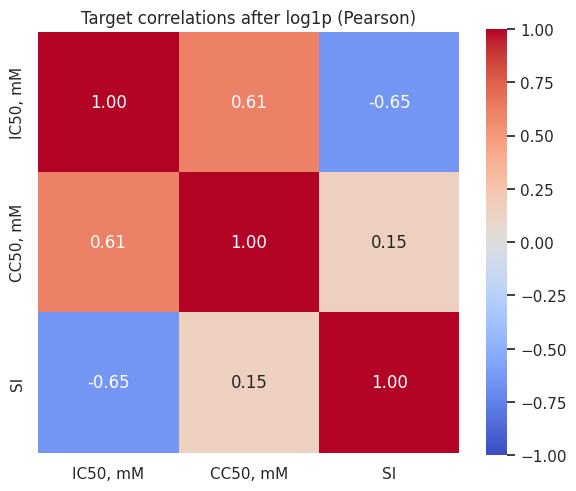

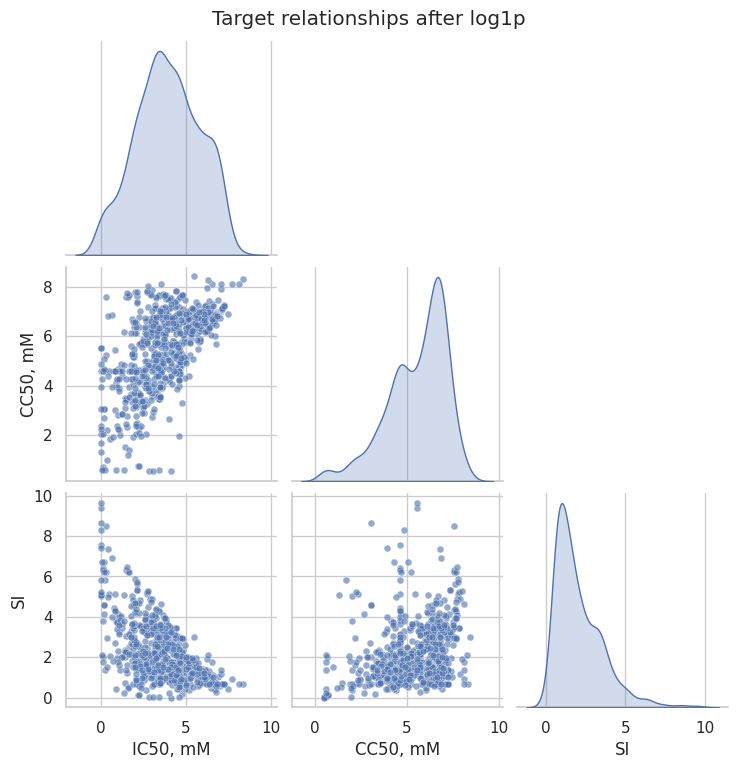

In [ ]:
target_log = np.log1p(train[target_cols].copy())


if (train[target_cols] < 0).any().any():
    print("Внимание: в target-переменных есть отрицательные значения. Проверьте корректность log1p.")

pearson_corr = target_log.corr(method="pearson")
spearman_corr = target_log.corr(method="spearman")

print("Pearson correlation matrix after log1p:")
display(pearson_corr.round(4))

print("Spearman correlation matrix after log1p:")
display(spearman_corr.round(4))


plt.figure(figsize=(6, 5))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Target correlations after log1p (Pearson)")
plt.tight_layout()
plt.show()


plot_targets = target_log.sample(n=min(1000, len(target_log)), random_state=42)
sns.pairplot(plot_targets, corner=True, diag_kind="kde", plot_kws={"alpha": 0.6, "s": 25})
plt.suptitle("Target relationships after log1p", y=1.02)
plt.show()


После логарифмирования между целевыми переменными сохраняются заметные, но не слишком сильные связи.
Наиболее выраженная положительная корреляция наблюдается между IC50, mM и CC50, mM (r = 0.61). Это означает, что соединения с более высоким IC50 обычно имеют и более высокий CC50, то есть между этими двумя показателями есть умеренная согласованность.

Самая важная связь для интерпретации качества соединений — отрицательная корреляция между IC50, mM и SI (r = -0.65). Это логично: чем выше IC50, тем ниже селективность, а значит соединение становится менее предпочтительным с точки зрения активности/безопасности.

Связь между CC50, mM и SI слабая (r = 0.15). Это говорит о том, что селективный индекс зависит не только от токсичности, но и в значительной степени от активности, поэтому одного CC50 недостаточно для хорошего объяснения SI.

По pairplot видно:

- зависимость IC50 и CC50 действительно восходящая, но с заметным разбросом;
- зависимость IC50 и SI убывающая и достаточно выраженная;
- распределение SI после log1p стало заметно более компактным, но на scatter-графике всё ещё видно правостороннее скопление и несколько выбросов;
между CC50 и SI точечное облако очень размыто, что подтверждает слабую линейную связь.

## 6. Константные и почти константные признаки


Признаки, которые почти не меняются и могут нести мало полезной информации
1) Константные признаки - одно и то же значение во всех строках
2) Почти константные признаки - одно значение встречается более чем в 98% случаев

In [ ]:
dominance_threshold = 0.98

constant_features = []
for col in feature_cols:
    if train[col].nunique(dropna=False) == 1:
        constant_features.append(col)

near_constant_rows = []
near_constant_features = []

for col in feature_cols:
    value_counts = train[col].value_counts(dropna=False, normalize=True)
    top_value = value_counts.index[0]
    top_share = value_counts.iloc[0]

    if top_share > dominance_threshold and col not in constant_features:
        near_constant_features.append(col)
        near_constant_rows.append({
            "feature": col,
            "top_value": top_value,
            "top_share_%": round(top_share * 100, 2)
        })

print(f"Константные признаки: {len(constant_features)}")
constant_df = pd.DataFrame({
    "feature": constant_features,
    "value": [train[col].iloc[0] for col in constant_features]
})
display(constant_df)

print(f"Почти константные признаки (> {int(dominance_threshold * 100)}% одного значения): {len(near_constant_features)}")
near_constant_df = pd.DataFrame(near_constant_rows).sort_values("top_share_%", ascending=False)
display(near_constant_df)


Константные признаки: 18


,feature,value
0,NumRadicalElectrons,0
1,SMR_VSA8,0
2,SlogP_VSA9,0
3,fr_N_O,0
4,fr_SH,0
5,fr_azide,0
6,fr_barbitur,0
7,fr_benzodiazepine,0
8,fr_diazo,0
9,fr_dihydropyridine,0


Почти константные признаки (> 98% одного значения): 22


,feature,top_value,top_share_%
3,fr_HOCCN,0.0,99.87
2,fr_Ar_COO,0.0,99.87
20,fr_tetrazole,0.0,99.87
14,fr_oxazole,0.0,99.87
19,fr_term_acetylene,0.0,99.87
4,fr_aldehyde,0.0,99.73
10,fr_hdrzine,0.0,99.73
8,fr_epoxide,0.0,99.73
9,fr_guanido,0.0,99.60
11,fr_nitrile,0.0,99.47


## 9. EDA summary


In [ ]:

eda_summary = pd.DataFrame([
    {"metric": "Train size", "value": f"{train.shape[0]} rows x {train.shape[1]} columns"},
    {"metric": "Test size", "value": f"{test.shape[0]} rows x {test.shape[1]} columns"},
    {"metric": "Number of features", "value": len(feature_cols)},
    {"metric": "Target variables", "value": ", ".join(target_cols)},
    {"metric": "ID columns", "value": ", ".join(id_cols)},
    {"metric": "Features with missing values", "value": len(missing_report)},
    {"metric": "Constant features", "value": len(constant_features)},
    {"metric": "Near-constant features (>98%)", "value": len(near_constant_features)},
    {"metric": "Numeric features", "value": len(numeric_features)},
    {"metric": "Categorical features", "value": len(categorical_features)},
    {"metric": "Text-like features", "value": len(text_like_features)},
])

display(eda_summary)

print("\nREADME summary:")
print(f"- Train: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"- Test: {test.shape[0]} rows, {test.shape[1]} columns")
print(f"- Features: {len(feature_cols)}")
print(f"- Targets: {', '.join(target_cols)}")
print(f"- Missing values were found in {len(missing_report)} feature-dataset pairs and filled with median")
print(f"- Constant features: {len(constant_features)}")
print(f"- Near-constant features (>98% one value): {len(near_constant_features)}")
print("- All features are numeric; no categorical or text features were found")
print("- log1p is recommended for IC50, CC50, and SI due to right-skewed distributions")


,metric,value
0,Train size,751 rows x 214 columns
1,Test size,250 rows x 211 columns
2,Number of features,210
3,Target variables,"IC50, mM, CC50, mM, SI"
4,ID columns,index
5,Features with missing values,24
6,Constant features,18
7,Near-constant features (>98%),22
8,Numeric features,210
9,Categorical features,0



README summary:
- Train: 751 rows, 214 columns
- Test: 250 rows, 211 columns
- Features: 210
- Targets: IC50, mM, CC50, mM, SI
- Missing values were found in 24 feature-dataset pairs and filled with median
- Constant features: 18
- Near-constant features (>98% one value): 22
- All features are numeric; no categorical or text features were found
- log1p is recommended for IC50, CC50, and SI due to right-skewed distributions


## Итог

В датасете есть только числовые признаки, категориальных и текстовых колонок нет, поэтому дальнейшее моделирование можно строить без отдельной обработки категорий.


Целевые переменные представлены тремя таргетами: "IC50, mM", "CC50, mM", "SI".
В качестве идентификатора присутствует колонка index; других ID-колонок не обнаружено.


В train и test были пропуски в 12 признаках химических дескрипторов:
MaxAbsPartialCharge
MinAbsPartialCharge
MaxPartialCharge
MinPartialCharge
BCUT2D_MWLOW
BCUT2D_MWHI
BCUT2D_MRLOW
BCUT2D_MRHI
BCUT2D_LOGPLOW
BCUT2D_LOGPHI
BCUT2D_CHGLO
BCUT2D_CHGHI


Пропуски заполнены медианой, что хорошо подходит для числовых признаков и устойчиво к выбросам.


Найдено 18 константных признаков

Также найдено 22 почти константных признака, где одно значение встречается более чем в 98% случаев. Такие признаки можно рассматривать как кандидатов на удаление, но лучше проверить их значимость перед финальным отбором.


По target-анализу логарифмическая трансформация нужна:
IC50 сильно правосторонне-скошен
CC50 тоже имеет правый хвост
SI крайне асимметричен и без log1p плохо подходит для моделирования


После log1p распределения становятся более стабильными и удобными для ML.